In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
configure_matplotlib()

# Set figure directory 
SAVE_FIGURES = True
fig_path = SNRNA_FIGURE_DIR
from functools import partial
save_figure = partial(save_figure, dir_path=fig_path)

PROJECT_ROOT: /code
CODE_DIR: /code
CODE_DIR exists: True
Python path includes CODE_DIR: True


In [2]:
cpm_scl = CPM_SCL
plt.rcParams["image.cmap"] = CMAP_NAME

In [3]:
CMAP_NAME

'PiYG'

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import glob, os, sys
import scanpy as sc
import pandas as pd
import anndata
from scipy.stats import spearmanr

import processing, utils, plotting, heatmap
import pseudoclusters, test_structures
print(f"scanpy version: {sc.__version__}")


scanpy version: 1.11.3


In [5]:
SNRNA_DATA_DIR

'/data/snRNAseq_LCNE_batchcorrected'

# Data Loading and Preprocessing

Loading snRNA-seq data...


/tmp/ipykernel_94/3187458434.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


Data shape: (4845, 1502)
Preparing data for analysis...
Creating UMAP visualization...


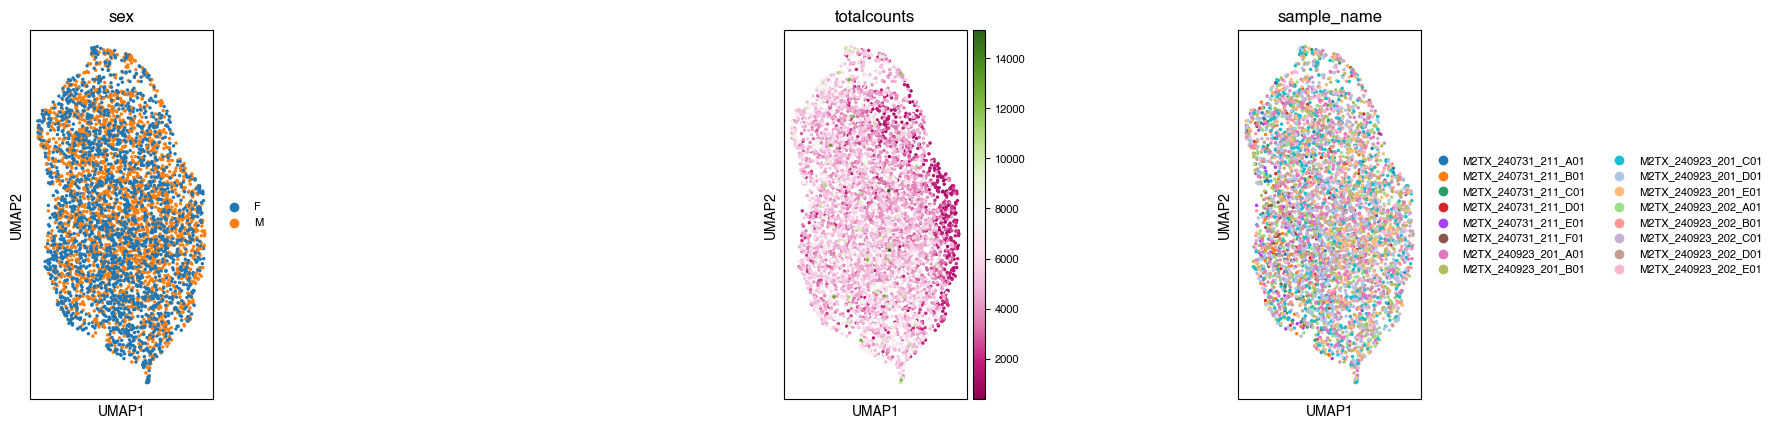

In [6]:
print("Loading snRNA-seq data...")
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")

adata_foo = sc.read_h5ad(myfilename)
adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})
adata_BN = anndata.AnnData(adata_foo.layers['BN'])  # np.sum(adata_BN.X,1)=1,1,1..
adata_BN.obs = adata_foo.obs.copy()
adata_BN.obsm = adata_foo.obsm.copy()
adata_BN.var = adata_foo.var.copy()

print(f"Data shape: {adata_BN.shape}")

# Prepare data for analysis
print("Preparing data for analysis...")
adata_sc = adata_BN.copy()
# adata_sc.raw=adata_sc.copy()
adata_sc.layers['originalBN']=adata_sc.X.copy()   # BN (sum ot 1)
## this is NEW 
adata_sc.raw=adata_foo.copy()  # actual raw.. 

sc.pp.scale(adata_sc, zero_center=True, max_value=10)
sc.tl.pca(adata_sc, n_comps=50, svd_solver='arpack')

# Basic UMAP visualization
print("Creating UMAP visualization...")
ax = sc.pl.umap(
    adata_sc, 
    color=["sex", 'totalcounts', 'sample_name'],
    ncols=3,
    show=False
)
for a in ax:
    a.set_aspect('equal')
# save_figure("umap_basic")

In [7]:
adata_foo.X.max()

795.0

In [8]:
np.sum(adata_sc.layers['originalBN'],1)

array([1.        , 1.        , 0.99999994, ..., 1.        , 1.        ,
       0.9999999 ], dtype=float32)

In [9]:
np.sum(adata_sc.X,1)

array([-443.38055, -448.03986, -141.85358, ...,  -99.45148,  375.75043,
        179.57626], dtype=float32)

# sanity check: instead of BN probability, use the raw counts (TP10k and then log1p) for the PCA
(just wanted to check we get the consistent results and confirm we can use BN) 

In [10]:
# Sanity check: robustness of PCA to preprocessing (BN vs log-normalized counts)
print("\nSanity check: BN-PCA vs log(CP10k)-PCA on same HVGs")
from scipy import sparse
# 1) BN PCA already computed above on adata_sc (scaled BN)
X_pca_bn = adata_sc.obsm["X_pca"]
vr_bn = adata_sc.uns["pca"]["variance_ratio"]
# 2) Build a comparison object on the same HVG genes (same gene set/order)
adata_std = adata_foo[:, adata_sc.var_names].copy()

# Choose a starting matrix for the "standard" pipeline.
# Priority: explicit counts layer > .raw.X > adata_foo.X
used_counts = False
used_raw = False
if "counts" in adata_std.layers.keys():
    adata_std.X = adata_std.layers["counts"].copy()
    used_counts = True
    print("Using adata_foo.layers['counts'] as input")
elif adata_std.raw is not None:    
    adata_std.X = adata_std.raw[:,adata_std.var_names].X.copy()
    used_raw = True
    print("Using adata_foo.raw.X as input")
else:
    print("Using adata_foo.X as input")

# Heuristic: detect if X looks like (nonnegative) integer counts, even if stored as float.
# This lets us override a stale adata.uns['log1p'] flag (common if objects were reused).
def _is_integer_like_counts(X, max_check=200000, tol=1e-6):
    if sparse.issparse(X):
        data = X.data
    else:
        data = np.asarray(X).ravel()
    if data.size == 0:
        return False
    if data.size > max_check:
        rng = np.random.default_rng(0)
        data = rng.choice(data, size=max_check, replace=False)
    if np.nanmin(data) < -tol:
        return False
    # ignore zeros for the integer-likeness check
    nz = data[np.abs(data) > tol]
    if nz.size == 0:
        return True
    return np.all(np.abs(nz - np.round(nz)) < tol)

counts_like = used_counts or used_raw or _is_integer_like_counts(adata_std.X)
if counts_like:
    # Ensure Scanpy doesn't think we're double-logging due to stale metadata
    if "log1p" in adata_std.uns:
        print("Found adata_std.uns['log1p'] but X looks counts-like; removing flag and applying normalize_total+log1p")
        adata_std.uns.pop("log1p", None)
    sc.pp.normalize_total(adata_std, target_sum=1e4)
    sc.pp.log1p(adata_std)
    print("Applied normalize_total(target_sum=1e4) + log1p")
else:
    if isinstance(adata_std.uns.get("log1p", None), dict):
        print("Detected adata_std.uns['log1p']; treating X as already log-normalized (skipping normalize_total/log1p)")
    else:
        print("NOTE: X does not look integer-like and no log1p flag found; comparison may be ambiguous.")

# Scaling: zero-centering sparse matrices densifies. If the matrix is small enough, densify explicitly for a fair centered PCA.
is_sparse = sparse.issparse(adata_std.X)
n_obs, n_vars = adata_std.n_obs, adata_std.n_vars
dense_ok = is_sparse and (n_obs * n_vars <= 10_000_000)  # ~80MB if float64; less if float32
if dense_ok:
    print(f"Densifying for centered PCA ({n_obs} x {n_vars})")
    adata_std.X = adata_std.X.toarray().astype(np.float32, copy=False)
    is_sparse = False

if is_sparse:
    print("adata_std.X is sparse and large; using scale(zero_center=False) and PCA(zero_center=False) to avoid densifying")
    sc.pp.scale(adata_std, zero_center=False, max_value=10)
    zero_center_pca = False
else:
    sc.pp.scale(adata_std, zero_center=True, max_value=10)
    zero_center_pca = True

sc.tl.pca(adata_std, n_comps=50, svd_solver="arpack", zero_center=zero_center_pca)

X_pca_std = adata_std.obsm["X_pca"]
vr_std = adata_std.uns["pca"]["variance_ratio"]

# 3) Compare explained variance and PC score agreement
n_check = 10
print(f"Variance explained (top {n_check} PCs): BN={vr_bn[:n_check].sum():.3f}, log(CP10k)={vr_std[:n_check].sum():.3f}")

# one-to-one correlation (note: sign flips are arbitrary)
corr_1to1 = np.array([np.corrcoef(X_pca_bn[:, i], X_pca_std[:, i])[0, 1] for i in range(n_check)])
print("PC score corr (BN vs log(CP10k)), 1-to-1:")
print(np.round(corr_1to1, 3))
print("Abs corr:")
print(np.round(np.abs(corr_1to1), 3))

# best-match correlation (detects possible PC re-ordering)
C = np.corrcoef(X_pca_bn[:, :n_check].T, X_pca_std[:, :n_check].T)[:n_check, n_check:]
best_match = np.max(np.abs(C), axis=1)
best_j = np.argmax(np.abs(C), axis=1)
print("Best-match abs corr for each BN PC among log(CP10k) PCs:")
print(np.round(best_match, 3))
print("Best-match indices (0-based):")
print(best_j)

print("\nCorrelation matrix (BN PCs x log(CP10k) PCs), rounded:")
print(np.round(C, 2))


Sanity check: BN-PCA vs log(CP10k)-PCA on same HVGs
Using adata_foo.X as input
Found adata_std.uns['log1p'] but X looks counts-like; removing flag and applying normalize_total+log1p
Applied normalize_total(target_sum=1e4) + log1p
Densifying for centered PCA (4845 x 1502)
Variance explained (top 10 PCs): BN=0.798, log(CP10k)=0.098
PC score corr (BN vs log(CP10k)), 1-to-1:
[ 0.98   0.903  0.201 -0.287  0.069 -0.516 -0.589  0.079 -0.153  0.051]
Abs corr:
[0.98  0.903 0.201 0.287 0.069 0.516 0.589 0.079 0.153 0.051]
Best-match abs corr for each BN PC among log(CP10k) PCs:
[0.98  0.903 0.643 0.818 0.527 0.516 0.589 0.422 0.313 0.066]
Best-match indices (0-based):
[0 1 4 2 3 5 6 6 9 4]

Correlation matrix (BN PCs x log(CP10k) PCs), rounded:
[[ 0.98  0.05 -0.08  0.01 -0.04  0.01 -0.05 -0.02  0.01  0.03]
 [-0.08  0.9  -0.08 -0.04 -0.3   0.01 -0.03 -0.01  0.07 -0.01]
 [ 0.01 -0.32  0.2  -0.19 -0.64 -0.09  0.09  0.13  0.21 -0.04]
 [-0.07 -0.14 -0.82 -0.29 -0.08 -0.23 -0.16 -0.03 -0.03  0.02]
 [


Plotting PC1/PC2 for BN and log(CP10k) PCA...


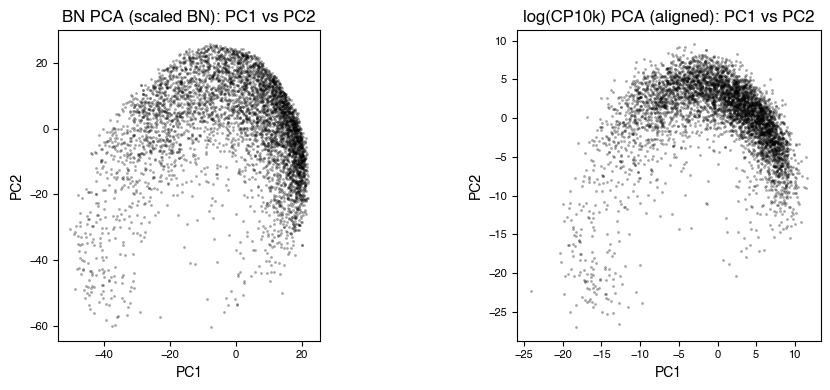

In [11]:

# 4) Visualize PC1/PC2 side-by-side (BN vs log(CP10k))
print("\nPlotting PC1/PC2 for BN and log(CP10k) PCA...")

# Align sign of standard PCs to BN PCs for the first two components (makes plots easier to compare)
X_std_aligned = X_pca_std.copy()
for i in [0, 1]:
    r = np.corrcoef(X_pca_bn[:, i], X_std_aligned[:, i])[0, 1]
    if np.isfinite(r) and (r < 0):
        X_std_aligned[:, i] *= -1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, X, title in [
    (axes[0], X_pca_bn, "BN PCA (scaled BN): PC1 vs PC2"),
    (axes[1], X_std_aligned, "log(CP10k) PCA (aligned): PC1 vs PC2"),
]:
    ax.scatter(X[:, 0], X[:, 1], s=4, c="k", alpha=0.35, linewidths=0)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


Trajectory score agreement: BN vs log(CP10k)
Spearman (best orientation) = 0.985  (p=0.00e+00), flipped=False
Pearson  (same orientation) = 0.985


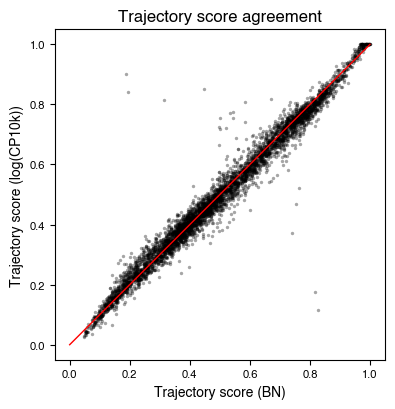

In [12]:

# 5) Trajectory score agreement (pseudoclusters) on BN vs log(CP10k) PCA
print("\nTrajectory score agreement: BN vs log(CP10k)")
n_dims_traj = 10
n_points_traj = 10000
deg_traj = 3

# Fit trajectories
trajectory_bn = pseudoclusters.fit_trajectory_curve(adata_sc, deg=deg_traj, n_dims=n_dims_traj)
projections_bn = pseudoclusters.calculate_projection_scores(trajectory_bn, n_points=n_points_traj)
scores_bn_ord = projections_bn["scores"].copy()
scores_bn_orig = np.empty_like(scores_bn_ord)
scores_bn_orig[trajectory_bn["order"]] = scores_bn_ord

trajectory_std = pseudoclusters.fit_trajectory_curve(adata_std, deg=deg_traj, n_dims=n_dims_traj)
projections_std = pseudoclusters.calculate_projection_scores(trajectory_std, n_points=n_points_traj)
scores_std_ord = projections_std["scores"].copy()
scores_std_orig = np.empty_like(scores_std_ord)
scores_std_orig[trajectory_std["order"]] = scores_std_ord

# Align by cell IDs just in case ordering differs
scores_bn_s = pd.Series(scores_bn_orig, index=adata_sc.obs_names, name="bn")
scores_std_s = pd.Series(scores_std_orig, index=adata_std.obs_names, name="std")
common = scores_bn_s.index.intersection(scores_std_s.index)
bn_v = scores_bn_s.loc[common].values
std_v = scores_std_s.loc[common].values

sp_0, sp_p0 = spearmanr(bn_v, std_v)
sp_1, sp_p1 = spearmanr(bn_v, 1.0 - std_v)
if np.abs(sp_1) > np.abs(sp_0):
    std_aligned_v = 1.0 - std_v
    used_flip = True
    sp = sp_1
    sp_p = sp_p1
else:
    std_aligned_v = std_v
    used_flip = False
    sp = sp_0
    sp_p = sp_p0

pe = np.corrcoef(bn_v, std_aligned_v)[0, 1]
print(f"Spearman (best orientation) = {sp:.3f}  (p={sp_p:.2e}), flipped={used_flip}")
print(f"Pearson  (same orientation) = {pe:.3f}")

# Scatter plot of trajectory scores
plt.figure(figsize=(4.5, 4.2))
plt.scatter(bn_v, std_aligned_v, s=6, c="k", alpha=0.35, linewidths=0)
plt.plot([0, 1], [0, 1], "r-", lw=1)
plt.xlabel("Trajectory score (BN)")
plt.ylabel("Trajectory score (log(CP10k))")
plt.title("Trajectory score agreement")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

# PCA Exploratory Analysis

Exploring PCA dimensions...
Saving figure to: /results/figures/snRNAseq/pca_dimensions.svg
Saving figure to: /results/figures/snRNAseq/pca_dimensions.png


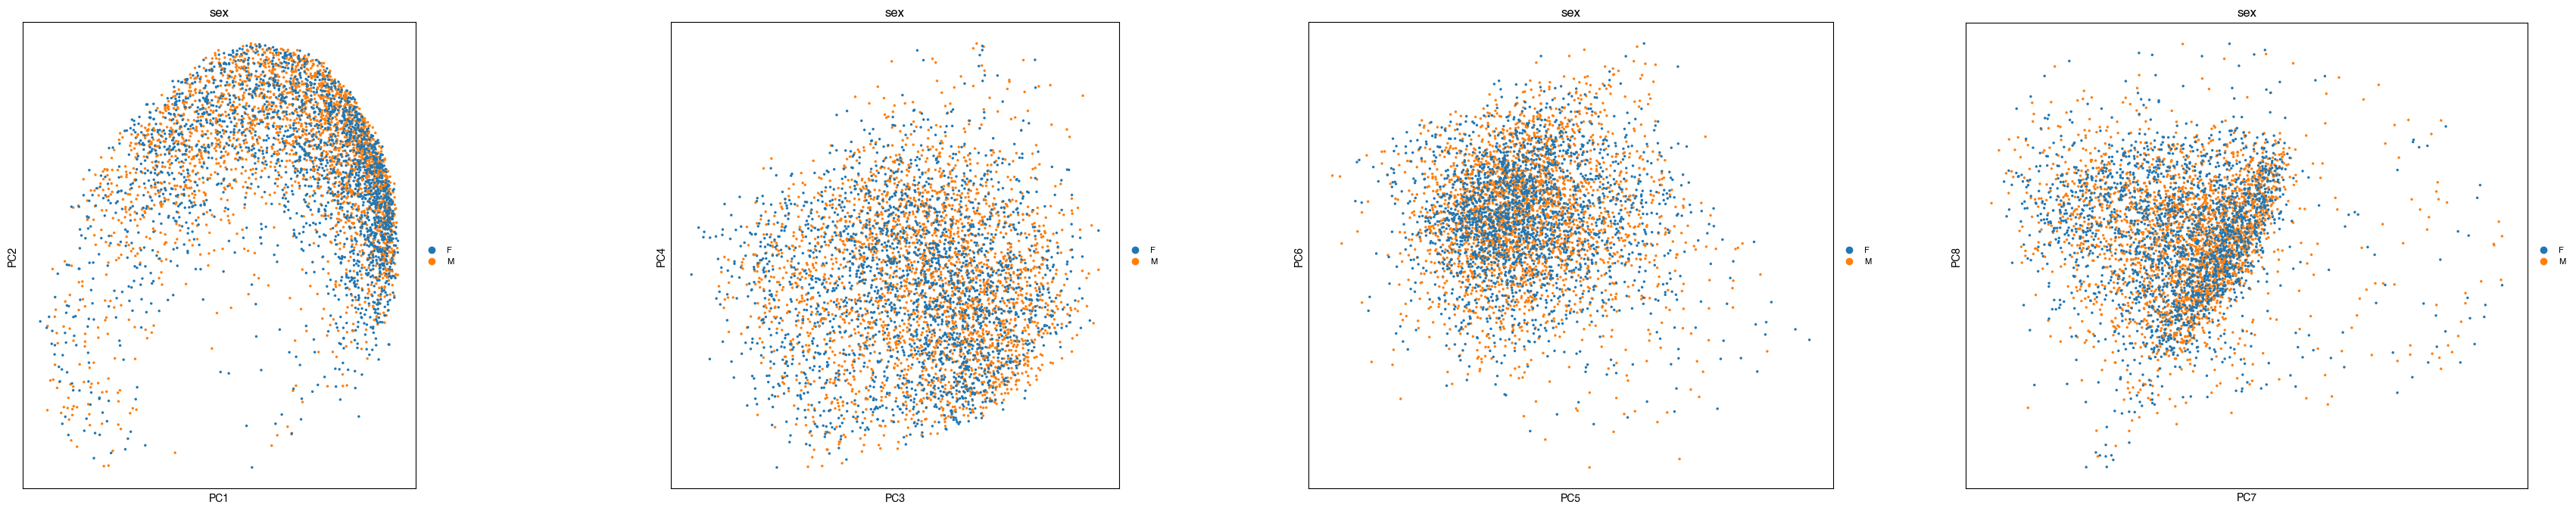

In [13]:
# PCA Exploratory Analysis
print("Exploring PCA dimensions...")

# Plot first few PCA dimensions
with plt.rc_context({"figure.figsize": (10, 8)}):    
    ax = sc.pl.pca(adata_sc, dimensions=((0, 1), (2, 3), (4, 5), (6, 7)), 
                  show=False, color='sex')
    for a in ax: 
        a.set_aspect('equal')
    save_figure("pca_dimensions")
    plt.show()


In [14]:
print(f"Variance explained by top 10 PCs: {adata_sc.uns['pca']['variance_ratio'][:10].sum():.3f}")
# check which genes have high loading on PC1 and PC2
print('PC1 genes:',adata_sc.var_names[np.argsort(np.abs(adata_sc.varm['PCs'][:,0]))[::-1]][:5])
print('PC2 genes:',adata_sc.var_names[np.argsort(np.abs(adata_sc.varm['PCs'][:,2]))[::-1]][:5])

Variance explained by top 10 PCs: 0.798
PC1 genes: Index(['Gpc6', 'B3galt1', 'Trhr', 'Neto1', 'Hs6st3'], dtype='object')
PC2 genes: Index(['Rgs22', 'Gm44577', 'AC149090.1', 'CN725425', 'Cntnap5c'], dtype='object')


# Trajectory Analysis with Pseudoclusters


In [15]:
# Trajectory Analysis with Pseudoclusters
print("Performing trajectory analysis with pseudoclusters...")

# Set dimensionality for trajectory analysis
n_dims = 10
print(f"Using {n_dims} PCA dimensions explaining {adata_sc.uns['pca']['variance_ratio'][:n_dims].sum():.3f} of variance")

# Fit trajectory curve and calculate projections
trajectory = pseudoclusters.fit_trajectory_curve(adata_sc, deg=3, n_dims=n_dims)
projections = pseudoclusters.calculate_projection_scores(trajectory, n_points=10000)
scores_0_1 = projections['scores'].copy()

fittedcurve = projections['fitted_curve']

# Visualize projections in PCA space
data = adata_sc.obsm['X_pca'][trajectory['order'], :n_dims]


Performing trajectory analysis with pseudoclusters...
Using 10 PCA dimensions explaining 0.798 of variance


# how much the curve can explain the PCs 1-10?

Text(0.5, 0, 'pseudocluster score')

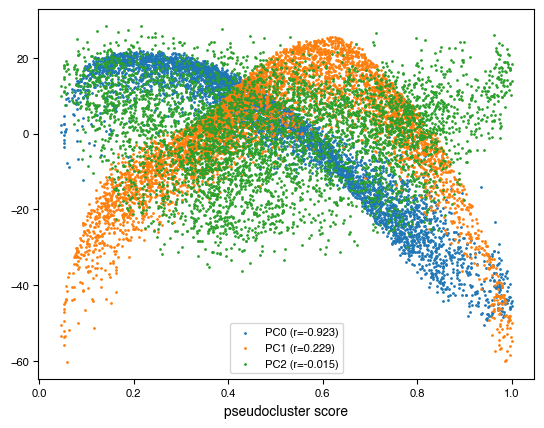

In [16]:
for k in range(3):
    pc_cor = np.corrcoef(scores_0_1,adata_sc.obsm['X_pca'][trajectory['order'], k])[0,1]
    plt.scatter(scores_0_1,adata_sc.obsm['X_pca'][trajectory['order'], k],
            s=1, label = f'PC{k} (r={np.around(pc_cor, 3)})')
plt.legend()
plt.xlabel('pseudocluster score')

In [17]:
X_pca_ord = adata_sc.obsm['X_pca'][trajectory['order']]  # (N, n_pcs)
# PCs (N × D) and per-PC polynomial predictions at each cell's t
D = 10 # n_pcs_to_eval
Y = X_pca_ord[:, :D]

# Use provided polynomials when available, else fit on the fly
Yhat_cols = []
for k in range(D):
    y = Y[:, k]
    if k < len(trajectory['polynomials']):
        coeffs = np.asarray(trajectory['polynomials'][k])
    else:
        coeffs = np.polyfit(projections['t_opt'], y, deg=deg)
    Yhat_cols.append(np.polyval(coeffs, projections['t_opt']))
Yhat = np.column_stack(Yhat_cols)

# Residuals and global metrics
R = Y - Yhat
RSS = float((R**2).sum())
TSS = float(((Y - Y.mean(axis=0, keepdims=True))**2).sum())

R2_global = np.nan if TSS == 0 else 1.0 - RSS / TSS
MSE_global = RSS / (Y.shape[0] * Y.shape[1])

print(f"Global R² (PC1–PC{D}): {R2_global:.4f}")
print(f"Global MSE (per entry): {MSE_global:.6g}")

Global R² (PC1–PC10): 0.4734
Global MSE (per entry): 62.5737


In [18]:
deg = len(trajectory['polynomials'][0]) - 1

print("*****  deg !!!!!", deg)


*****  deg !!!!! 3


Saving figure to: /output/figures/snRNAseq/R2_PCs.svg
Saving figure to: /output/figures/snRNAseq/R2_PCs.png


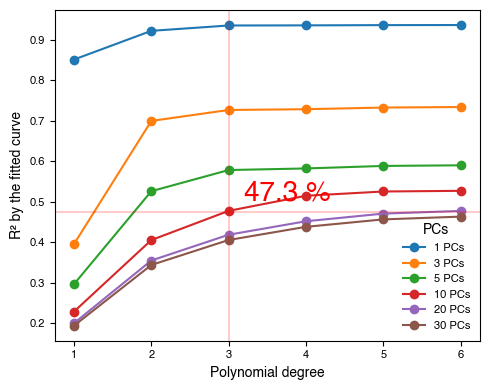

In [18]:
deglist = [1,2,3,4,5,6]
num_pc_list = [1,3,5,10,20,30]
r2_list = []

records = []
for num_pc in num_pc_list:
    Y = X_pca_ord[:, :num_pc]
    for deg in deglist:
        # fit per PC with degree=deg
        Yhat = np.column_stack([
            np.polyval(np.polyfit(projections['t_opt'], Y[:, k], deg=deg), projections['t_opt'])
            for k in range(num_pc)
        ])
        R = Y - Yhat
        RSS = float((R**2).sum())
        TSS = float(((Y - Y.mean(axis=0, keepdims=True))**2).sum())
        R2 = np.nan if TSS == 0 else 1.0 - RSS/TSS
        MSE = RSS / (Y.shape[0]*Y.shape[1])
        records.append({"num_pc": num_pc, "deg": deg, "R2": R2, "MSE": MSE})

df = pd.DataFrame(records).sort_values(["num_pc", "deg"])
plt.figure(figsize=(5,4))
for num_pc, grp in df.groupby("num_pc"):
    plt.plot(grp["deg"], grp["R2"], marker="o", label=f"{num_pc} PCs")
plt.axvline(3, alpha = .2, color ='red')
plt.axhline(R2_global, alpha = .2, color ='red')
plt.text(3+0.2,R2_global+.03, f'{np.around(R2_global,3)*100} %', color ='r', fontsize = 20)
plt.xlabel("Polynomial degree")
plt.ylabel("R² by the fitted curve")
plt.legend(title="PCs", frameon=False)
plt.tight_layout()
save_figure("R2_PCs")

# find gene R2

In [51]:
adata_sc.X.max()

10.0

In [62]:
x_genes = np.array(adata_sc.raw.X[trajectory['order']].todense())
x_genes = adata_sc.X[trajectory['order']].copy()
x_genes = adata_sc.layers['originalBN'][trajectory['order']].copy() * 1e+4



deg = len(trajectory['polynomials'][0])-1
T = (adata_sc.shape[1])
r2_list, mse_list = [], []
coeffs_list = []

for k in range(T):
    y = x_genes[:, k]
    coeffs = np.polyfit(scores_0_1, y, deg=deg)
    
    y_hat = np.polyval(coeffs, scores_0_1)
    resid = y - y_hat
    mse = np.mean(resid**2)
    denom = np.sum((y - y.mean())**2)
    r2 = 1.0 - np.sum(resid**2) / denom if denom > 0 else np.nan

    mse_list.append(mse)
    r2_list.append(r2)
    coeffs_list.append(coeffs)

for k in range(10):
    print(f"{adata_sc.var_names[k]}: R2={r2_list[k]:.4f}, MSE={mse_list[k]:.6g}")


0610040J01Rik: R2=0.5070, MSE=0.226343
1110019D14Rik: R2=0.4500, MSE=0.281832
1600002D24Rik: R2=0.1167, MSE=0.0367503
1700001C19Rik: R2=0.3309, MSE=0.0474082
1700006J14Rik: R2=0.1665, MSE=0.00567283
1700010J16Rik: R2=0.3372, MSE=0.0422342
1700016P03Rik: R2=0.3176, MSE=1.39218
1700020N01Rik: R2=0.4172, MSE=0.00226392
1700023F02Rik: R2=0.0431, MSE=0.0182125
1700026D11Rik: R2=0.1915, MSE=0.00770876


Text(0.5, 1.0, 'genes CAN be explained by the gradient')

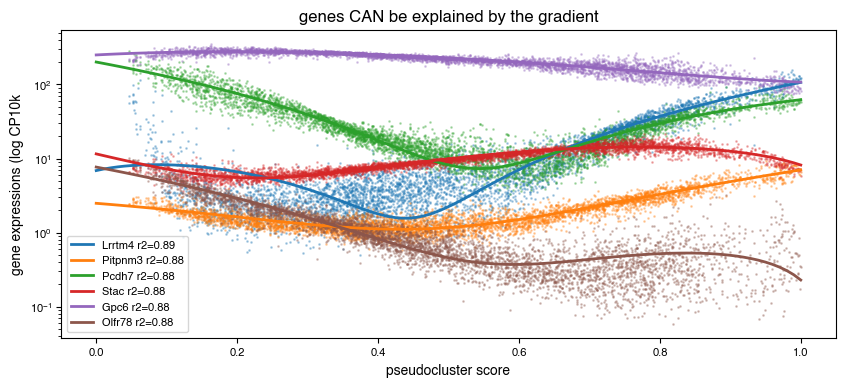

In [63]:
T = 6
gene_id_order = np.argsort(np.array(r2_list))[::-1]
high_R2_genes = [adata_sc.var_names[k] for k in gene_id_order[:T]]
low_R2_genes = [adata_sc.var_names[k] for k in gene_id_order[-T:]]


ts_line = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
for m in gene_id_order[:T]:
    y = x_genes[:, m]
    plt.scatter(scores_0_1, y, s=1, alpha=.3)
    coeffs = np.polyfit(scores_0_1, y, deg=deg)
    plt.plot(ts_line, np.polyval(coeffs, ts_line), linewidth=2,
             label=adata_sc.var_names[m] + f' r2={np.around(r2_list[m], 2)}')
plt.legend()
plt.yscale('log')
plt.xlabel('pseudocluster score')
plt.ylabel('gene expressions (log CP10)k')
plt.title('genes CAN be explained by the gradient')
save_figure("gene_R2s")

# Bootstrap Analysis of Trajectory Robustness

Performing bootstrap analysis of trajectory robustness...
Generating 100 bootstrap samples...
Saving figure to: /output/figures/snRNAseq/trajectory_bootstrap_std.svg
Saving figure to: /output/figures/snRNAseq/trajectory_bootstrap_std.png


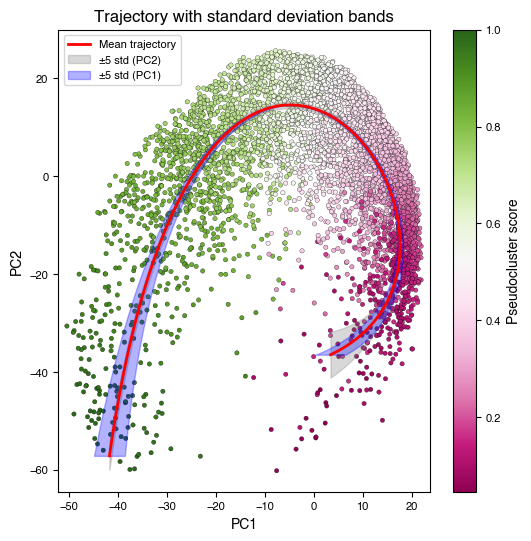

In [19]:
# Bootstrap Analysis of Trajectory Robustness
print("Performing bootstrap analysis of trajectory robustness...")

# Set up bootstrap parameters
std_scl = 5  # Standard deviation scale for visualization
trajectory = pseudoclusters.fit_trajectory_curve(adata_sc, deg=3, n_dims=n_dims)
projections = pseudoclusters.calculate_projection_scores(trajectory, n_points=1000)
if projections['scores'][0] >   0.5:  # keep the original order!
    foo = projections['scores']
else:
    foo = 1-projections['scores']
projections['scores'] = foo.copy()
data = adata_sc.obsm['X_pca'][trajectory['order'], :n_dims]
t_proj = trajectory['t_proj']
t_lin = projections['t_grid']
n_boot = 100

# Perform bootstrap sampling
print(f"Generating {n_boot} bootstrap samples...")
boot_curves = np.zeros((n_boot, len(t_lin), n_dims))
for i in range(n_boot):
    idx = np.random.choice(len(data), len(data), replace=True)
    data_bs = data[idx]
    t_bs = t_proj[idx]
    for d in range(n_dims):
        p = np.polyfit(t_bs, data_bs[:, d], 3)
        boot_curves[i, :, d] = np.polyval(p, t_lin)

# Calculate statistics
mean_curve = boot_curves.mean(axis=0)   # shape (n_t, n_dims)
std_curve = boot_curves.std(axis=0)    # shape (n_t, n_dims)

# Plot with standard deviation bands
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], s=10, c=projections['scores'],
            edgecolor='k', linewidth=0.2, cmap=CMAP_NAME)
plt.plot(mean_curve[:, 0], mean_curve[:, 1], 'r-', lw=2, label='Mean trajectory')

# PC2-variance band: vertical band around the curve in y
plt.fill_between(mean_curve[:, 0],
                 mean_curve[:, 1] - std_scl*std_curve[:, 1],
                 mean_curve[:, 1] + std_scl*std_curve[:, 1],
                 color='gray', alpha=0.3,
                 label=f'±{std_scl} std (PC2)')

# PC1-variance band: horizontal band around the curve in x
plt.fill_betweenx(mean_curve[:, 1],
                  mean_curve[:, 0] - std_scl*std_curve[:, 0],
                  mean_curve[:, 0] + std_scl*std_curve[:, 0],
                  color='blue', alpha=0.3,
                  label=f'±{std_scl} std (PC1)')

plt.colorbar(label='Pseudocluster score')
plt.axis('equal')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(loc='best')
plt.title('Trajectory with standard deviation bands')
save_figure("trajectory_bootstrap_std", dir_path=fig_path)
plt.show()

Computing 95% confidence intervals from bootstrap...
Saving figure to: /output/figures/snRNAseq/trajectory_bootstrap_ci.svg
Saving figure to: /output/figures/snRNAseq/trajectory_bootstrap_ci.png


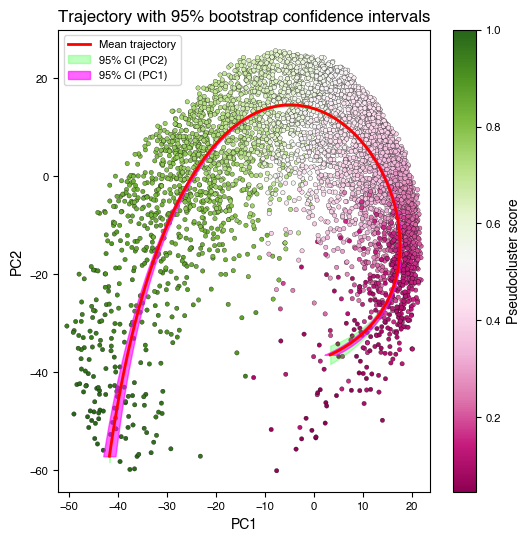

In [20]:
# Confidence Interval Analysis
print("Computing 95% confidence intervals from bootstrap...")

# Perform more thorough bootstrap with 10,000 samples for accurate CIs
n_boot = 10000
boot_curves = np.zeros((n_boot, len(t_lin), n_dims))
for i in range(n_boot):
    idx = np.random.choice(len(data), len(data), replace=True)
    data_bs = data[idx]
    t_bs = t_proj[idx]
    for d in range(n_dims):
        p = np.polyfit(t_bs, data_bs[:, d], 3)
        boot_curves[i, :, d] = np.polyval(p, t_lin)

# Compute percentiles for 95% CI
ci_lower = np.percentile(boot_curves, 2.5, axis=0)   # shape (n_t, n_dims)
ci_upper = np.percentile(boot_curves, 97.5, axis=0)  # shape (n_t, n_dims)
mean_curve = boot_curves.mean(axis=0)

# Plot with confidence intervals
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], s=10, c=projections['scores'],
            edgecolor='k', linewidth=0.2, cmap=CMAP_NAME)
plt.plot(mean_curve[:, 0], mean_curve[:, 1], 'r-', lw=2, label='Mean trajectory')

# PC2 95% CI band (vertical shading)
plt.fill_between(mean_curve[:, 0],
                 ci_lower[:, 1],
                 ci_upper[:, 1],
                 color='lime', alpha=0.25,
                 label='95% CI (PC2)')

# PC1 95% CI band (horizontal shading)
plt.fill_betweenx(mean_curve[:, 1],
                  ci_lower[:, 0],
                  ci_upper[:, 0],
                  color='magenta', alpha=0.6,
                  label='95% CI (PC1)')

plt.colorbar(label='Pseudocluster score')
plt.axis('equal')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Trajectory with 95% bootstrap confidence intervals')
plt.legend(loc='best')
save_figure("trajectory_bootstrap_ci")
plt.show()

# Clean Visualization of Pseudoclusters

Creating publication-quality pseudocluster visualization...
Saving figure to: /output/figures/snRNAseq/pseudocluster_pca_clean.svg
Saving figure to: /output/figures/snRNAseq/pseudocluster_pca_clean.png


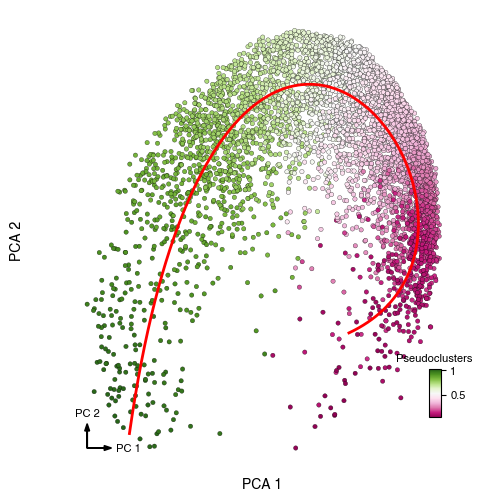

Saving figure to: /output/figures/snRNAseq/pseudocluster_distance.svg
Saving figure to: /output/figures/snRNAseq/pseudocluster_distance.png


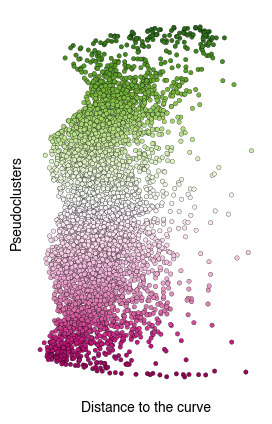

In [21]:
# Clean Visualization of Pseudoclusters
print("Creating publication-quality pseudocluster visualization...")

fs = 8  # Font size for labels
s = 10  # Point size for scatter
yourtitlename = 'Pseudoclusters'

# Create main PCA visualization
plt.figure(figsize=(6, 6))
plt.plot(fittedcurve[0], fittedcurve[1], 'r-', lw=2)
sca = plt.scatter(data[:, 0], data[:, 1], s=s, c=scores_0_1, 
                  edgecolor='k', linewidth=0.2, cmap=CMAP_NAME)
plt.axis('equal')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Add coordinate system arrows
x0, y0 = np.min(adata_sc.obsm['X_pca'], 0)[:2]
plt.arrow(x0, y0, 5, 0,
         head_width=1, width=0.1,
         length_includes_head=True, color='black')
plt.arrow(x0, y0, 0, 5,
         head_width=1, width=0.1,
         length_includes_head=True, color='black')

plt.text(x0+6, y0, 'PC 1', va='center', ha='left', fontsize=fs)
plt.text(x0, y0+6, 'PC 2', va='bottom', ha='center', fontsize=fs)

# Clean up plot appearance
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().set_xticks([])
plt.gca().set_yticks([])

# Add custom colorbar
cbar_ax = plt.gcf().add_axes([0.79, 0.20, 0.02, 0.08])
plt.gcf().colorbar(sca, cax=cbar_ax, ticks=[0.01, 0.5, 0.99])
cbar_ax.set_yticklabels(['0', '0.5', '1'])  # vertically oriented colorbar
cbar_ax.set_title(yourtitlename, fontsize=fs)
cbar_ax.tick_params(labelsize=fs)

save_figure("pseudocluster_pca_clean")
plt.show()

# Create distance scatter plot
plt.figure(figsize=(3, 5))
sca = plt.scatter(np.sqrt(projections['min_d2']), scores_0_1, 
                  c=scores_0_1, edgecolor='k', linewidth=0.2, s=s, cmap=CMAP_NAME)
plt.ylabel(yourtitlename)
plt.xlabel('Distance to the curve')

# Clean up plot appearance
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().set_xticks([])
plt.gca().set_yticks([])

save_figure("pseudocluster_distance")
plt.show()

In [22]:
# Save Pseudocluster Scores for External Use
print("Saving pseudocluster scores to CSV...")

# Create array with original cell ordering
scores_01_orig = np.empty_like(scores_0_1)
scores_01_orig[trajectory['order']] = scores_0_1

# Create dataframe and save to CSV
cellID_pc = pd.DataFrame({'cellID': adata_sc.obs.index, 'pseudoclusters': scores_01_orig})
output_file = os.path.join(TMP_OUT_DIR, 'cellID_pc_0722.csv')
cellID_pc.to_csv(output_file, index=False)
print(f"Saved pseudocluster scores to: {output_file}")

Saving pseudocluster scores to CSV...
Saved pseudocluster scores to: /output/cellID_pc_0722.csv


Visualizing pseudoclusters on UMAP...
Saving figure to: /output/figures/snRNAseq/pseudocluster_umap.svg
Saving figure to: /output/figures/snRNAseq/pseudocluster_umap.png


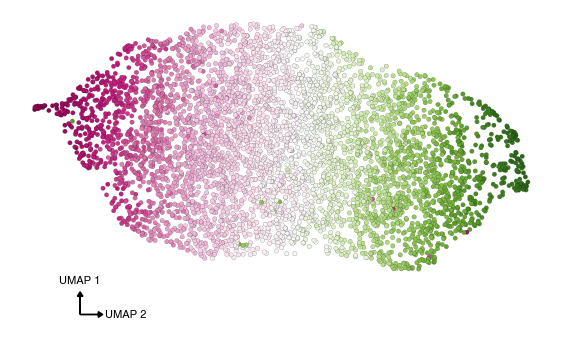

In [23]:
# Visualize Pseudoclusters on UMAP
print("Visualizing pseudoclusters on UMAP...")

plt.figure(figsize=(7, 5))
ax = plt.gca()
sca = ax.scatter(
    adata_sc.obsm['X_umap'][trajectory['order'], 1],
    adata_sc.obsm['X_umap'][trajectory['order'], 0],
    s=s, c=scores_0_1, cmap=CMAP_NAME, edgecolor='k', linewidth=0.1
)

# Clean up plot appearance
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Add coordinate system arrows
x0, y0 = np.min(adata_sc.obsm['X_umap'], 0)
ax.arrow(x0, y0, 1, 0, head_width=0.25, head_length=0.2,
         length_includes_head=True, width=0.001, color='black')
ax.arrow(x0, y0, 0, 1, head_width=0.25, head_length=0.2,
         length_includes_head=True, width=0.001, color='black')

ax.text(x0+1.1, y0, 'UMAP 2', va='center', ha='left', fontsize=fs)
ax.text(x0, y0+1.3, 'UMAP 1', va='bottom', ha='center', fontsize=fs)
ax.set_aspect('equal')

save_figure("pseudocluster_umap")
plt.show()

## Find Genes Correlated with Pseudoclusters

In [24]:
if hasattr(adata_sc.X, 'toarray'):
    expr = adata_sc.X.toarray()
else:
    expr = adata_sc.X
correlations = []
p_values = []
for i in range(expr.shape[1]):
    gene_expr = expr[:, i][trajectory['order']]
    r, p = spearmanr(scores_0_1, gene_expr)
    correlations.append(r)
    p_values.append(p)

correlations = np.array(correlations)
p_values = np.array(p_values)

# Create DataFrame of results
df = pd.DataFrame({'gene': adata_sc.var_names,'correlation': correlations,'p_value': p_values})
df_sorted = df.iloc[np.argsort(np.abs(df['correlation']))[::-1]]
print("Top 10 genes correlated with pseudoclusters:")
print(df_sorted.head(10))


TG =50
posgenes = df.iloc[np.argsort((df['correlation']))[::-1]][:TG]['gene']
neggenes = df.iloc[np.argsort((df['correlation']))][:TG]['gene']
u_genes = ['Lrrtm4', 'Vwc2', 'Sgcz', 'Mcc', 'Grik1', 'Pitpnc1', 'Lhfpl3']
u_genes =['Pcdh7', 'Pde8b', 'Cacna1i', 'Hrh1', 'Ust', 'Jun', 'Myo16']

T = len(u_genes)

Top 10 genes correlated with pseudoclusters:
          gene  correlation  p_value
1427      Trhr     0.951266      0.0
419      Epha6     0.937088      0.0
296      Chsy3    -0.931670      0.0
806       Gpc6    -0.927139      0.0
1084     Parm1    -0.927091      0.0
449       Fat3    -0.925906      0.0
1289  Slc16a10    -0.923305      0.0
1369    Tbc1d4    -0.922720      0.0
317   Cntnap5b     0.918272      0.0
365       Dab1    -0.910923      0.0


# instead of correlation, load posgenes and neggenes from csv

# save csv for yoh


# re-org the plotting of pos/neg/u-genes

In [25]:
print("Setting up plotting helpers...")
## using correlation based gene list 
posgenes_list = list(posgenes)
neggenes_list = list(neggenes)

## using curated gene list 
# posgenes_list = list(posgenes_yoh)
# neggenes_list = list(neggenes_yoh)

u_genes_list  = list(u_genes)
T = len(u_genes_list)


Setting up plotting helpers...


In [26]:

def _gene_expr(g):
    return adata_sc.layers["originalBN"][:, np.where(adata_sc.var_names == g)[0][0]]

def _clean(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

def plot_embedding_panel(embedding_key, s, shrink, save_name, fig_height=7):
    emb = adata_sc.obsm[embedding_key]
    fig, axes = plt.subplots(3, T, figsize=(2*T, fig_height))
    for r, (genes, sh) in enumerate(zip([posgenes_list, neggenes_list, u_genes_list], shrink)):
        for t, g in enumerate(genes[:T]):
            ax = axes[r, t]; ax.set_title(g)
            expr = _gene_expr(g); order = np.argsort(expr)
            sca = ax.scatter(
                emb[order,0], emb[order,1],
                c=expr[order]*cpm_scl,
                s=s, cmap="Greys",
                edgecolor="k", linewidth=0.1)
            ax.set_aspect("equal")
            cb = plt.colorbar(sca, shrink=sh)
            cb.ax.xaxis.set_label_position("top")
            cb.ax.set_xlabel("CPM", ha="center", va="bottom")
            _clean(ax)
    fig.tight_layout(); save_figure(save_name); plt.show()

def plot_gene_vs_pseudocluster_panel(s, save_name, fig_height=5):
    fig, axes = plt.subplots(3, T, figsize=(2*T, fig_height))
    for r, genes in enumerate([posgenes_list, neggenes_list, u_genes_list]):
        for t, g in enumerate(genes[:T]):
            ax = axes[r, t]; ax.set_title(g)
            idx = np.where(adata_sc.var_names == g)[0][0]
            y = adata_sc.layers["originalBN"][trajectory["order"], idx] * cpm_scl
            ax.scatter(scores_0_1, y, s=s,
                       color="white", edgecolor="k", linewidth=0.3)
            ax.set_ylabel("CPM"); ax.set_xlabel("Pseudoclusters")
    fig.tight_layout(); save_figure(save_name); plt.show()

## 1. umap

## 2. pca 

## 3. scatterr

## some curated genes 


In [27]:
# Curated gene sets by category
curated_genes = {
    "Axon guidance": ["Epha6", "Plxna2", "Robo1", "Epha7", "Plxna4", "Sema3c", "Slit2"],
    "Cell adhesion": ["Csmd3", "Il1rapl1", "Lrrtm4", "Ncam2", "Cdh13",
                      "Cdh6", "Cntn4", "Fat3", "Pcdh7", "Sdk2", "Tmem132d"],
    "ECM": ["Chsy3", "Col18a1", "Col6a5", "Hs3st5", "Hs6st3", "Ndst3"],
    "Ion channels": ["Hcn1", "Scn9a", "Kcnh1", "Kctd8"],
    "Neuromodulator signaling": ["Trhr", "Sctr", "Tacr3", "Tafa5", "Pdyn", "Htr2c", "Olfr78"],
    "Neurotransmitter\nsignaling": ["Gabrg1", "Glra2"],
    "Synaptic transmission": ["Cadps2", "Cadps"],
    "Transcription": ["Esr1", "Nrip1", "Tshz1", "Tshz2"],
    "Transporters": ["Slc16a10", "Slc39a12"],}

def plot_curated_embedding_panels(embedding_key, s, shrink, save_prefix, h=4):
    emb = adata_sc.obsm[embedding_key]
    missing_total = 0

    for category, genes in curated_genes.items():
        present = [g for g in genes if g in adata_sc.var_names]
        missing_total += len(genes) - len(present)
        if len(present) == 0:
            continue

        n = len(present)
        fig, axes = plt.subplots(1, n, figsize=(2*n, h))
        if n == 1:
            axes = np.array([axes])

        for ax, g in zip(axes, present):
            ax.set_title(g)
            expr = _gene_expr(g)
            order = np.argsort(expr)

            sca = ax.scatter(
                emb[order,0], emb[order,1],
                c=expr[order]*cpm_scl,
                s=s, cmap="Greys",
                edgecolor="k", linewidth=0.1
            )
            ax.set_aspect("equal")
            cb = plt.colorbar(sca, shrink=shrink)
            cb.ax.xaxis.set_label_position("top")
            cb.ax.set_xlabel("CPM", ha="center", va="bottom")
            _clean(ax)

        fig.suptitle(category)
        fig.tight_layout(rect=[0, 0, 1, 0.95])  
        fig.tight_layout()
        save_figure(f"{save_prefix}_{category.replace(' ','_').lower()}")
        plt.show()

    print(f"{missing_total} curated genes not found in adata_sc.var_names")


In [28]:
'Htr2c' in adata_sc.var_names

False

Visualizing curated gene sets on UMAP...
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_axon_guidance.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_axon_guidance.png


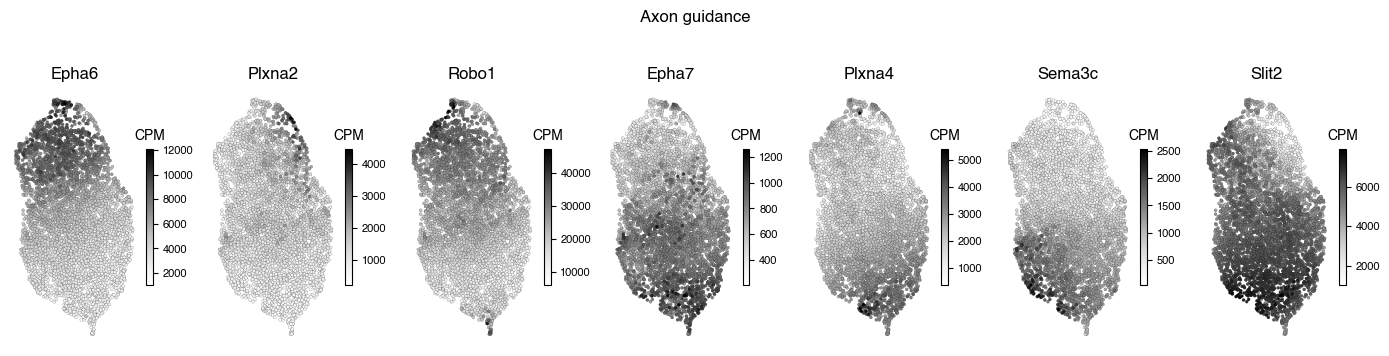

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_cell_adhesion.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_cell_adhesion.png


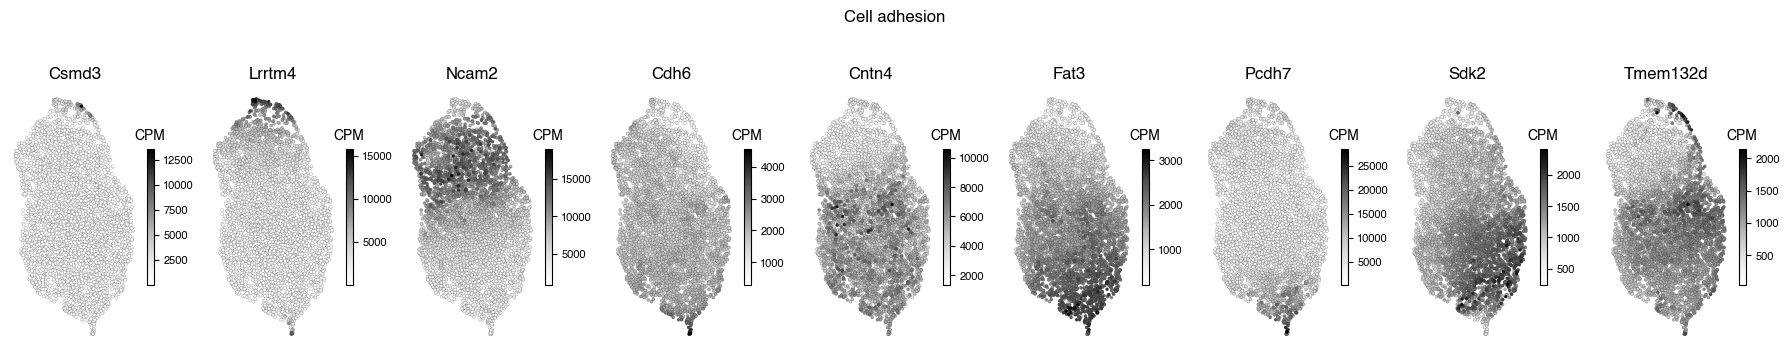

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_ecm.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_ecm.png


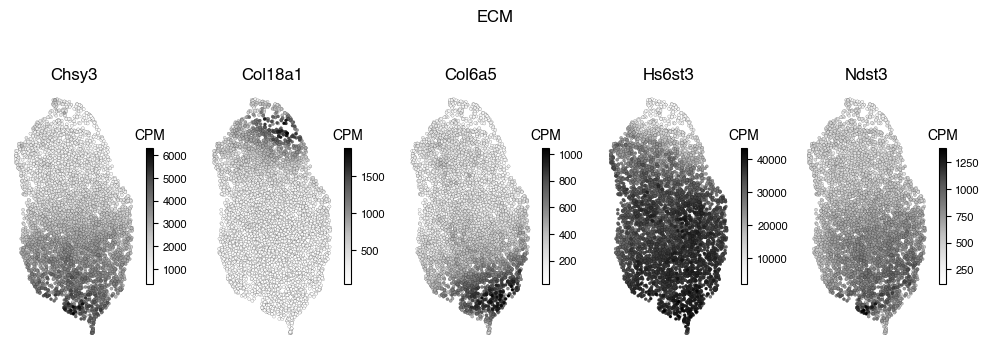

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_ion_channels.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_ion_channels.png


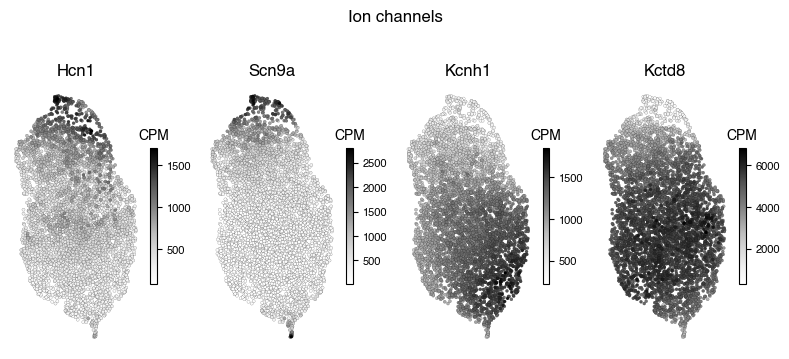

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_neuromodulator_signaling.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_neuromodulator_signaling.png


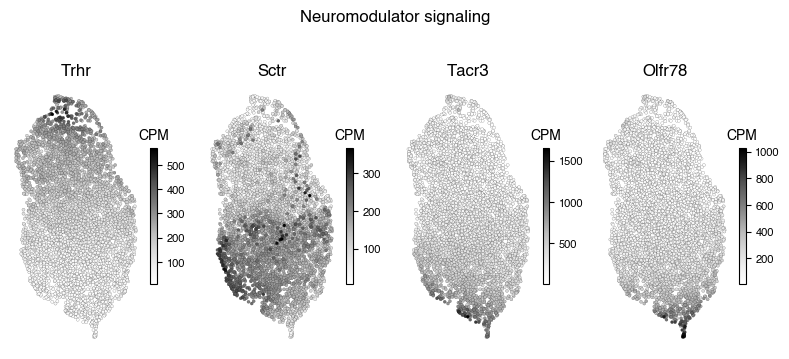

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_neurotransmitter
signaling.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_neurotransmitter
signaling.png


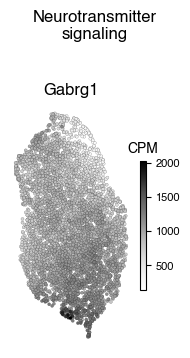

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_synaptic_transmission.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_synaptic_transmission.png


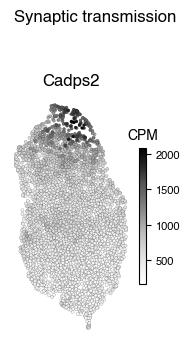

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_transcription.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_transcription.png


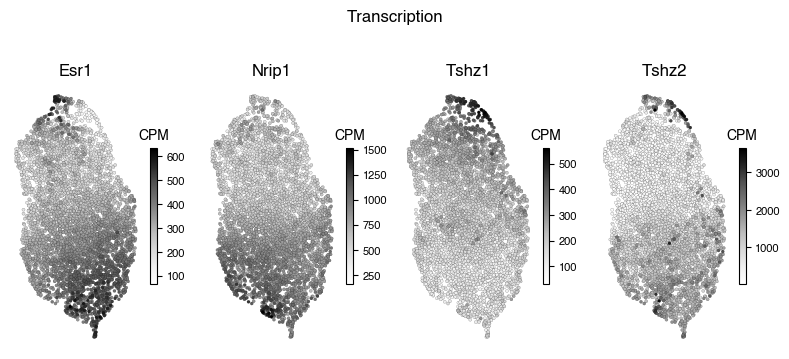

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_transporters.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_umap_transporters.png


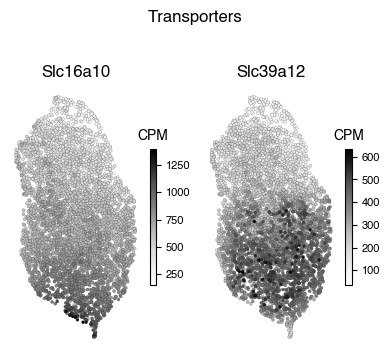

8 curated genes not found in adata_sc.var_names
Visualizing curated gene sets on PCA...
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_axon_guidance.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_axon_guidance.png


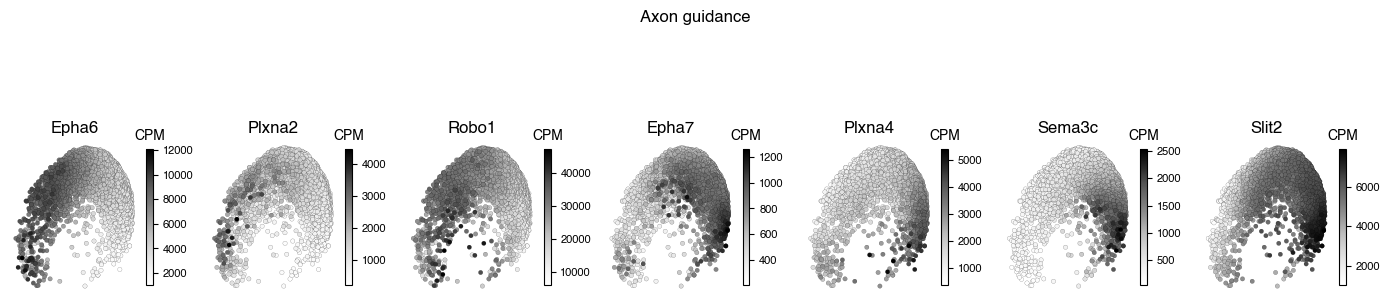

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_cell_adhesion.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_cell_adhesion.png


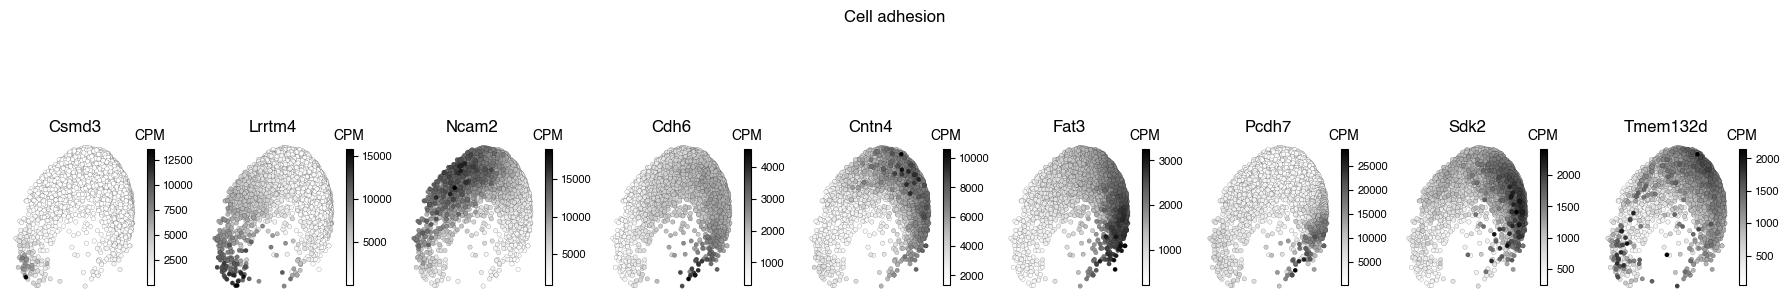

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_ecm.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_ecm.png


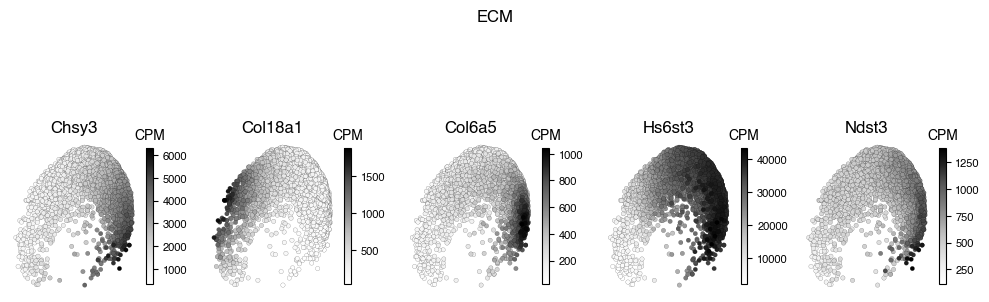

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_ion_channels.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_ion_channels.png


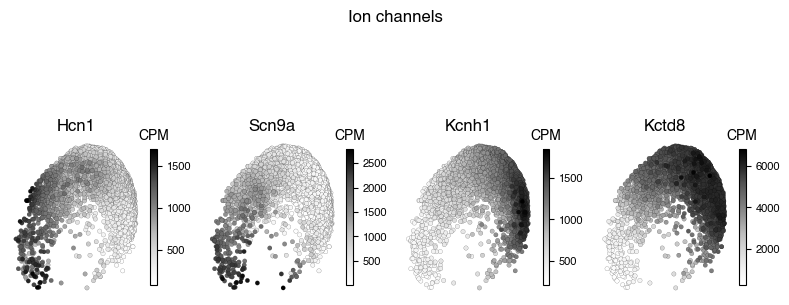

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_neuromodulator_signaling.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_neuromodulator_signaling.png


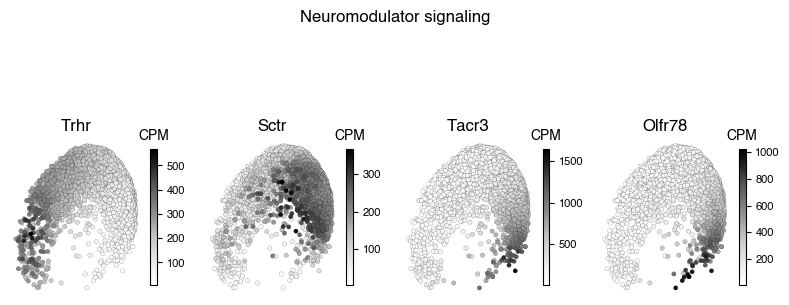

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_neurotransmitter
signaling.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_neurotransmitter
signaling.png


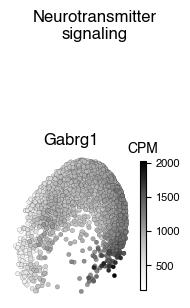

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_synaptic_transmission.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_synaptic_transmission.png


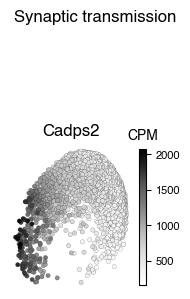

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_transcription.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_transcription.png


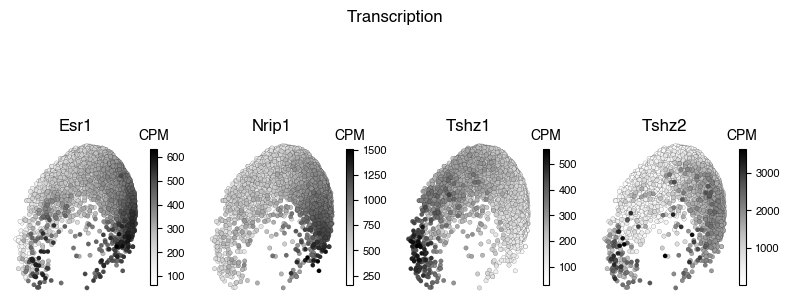

Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_transporters.svg
Saving figure to: /output/figures/snRNAseq/curated_gene_patterns_pca_transporters.png


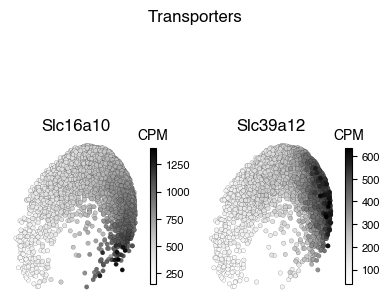

8 curated genes not found in adata_sc.var_names


In [29]:
print("Visualizing curated gene sets on UMAP...")
plot_curated_embedding_panels(
    embedding_key="X_umap",
    s=5,
    shrink=0.4,
    save_prefix="curated_gene_patterns_umap",
    h=4,
)

print("Visualizing curated gene sets on PCA...")
plot_curated_embedding_panels(
    embedding_key="X_pca",
    s=10,
    shrink=0.4,
    save_prefix="curated_gene_patterns_pca",
    h=4,
)

# run some sort of GO analyiss 
1. 100 postiive genes
2. 100 negative genes
3. 100 correlated genes

In [30]:
from matplotlib.colors import LinearSegmentedColormap
cmap_sele = plt.get_cmap(CMAP_NAME)
low_col = cmap_sele(0.0)   # RGBA for the "bottom" color
high_col = cmap_sele(1.0)  # RGBA for the "top" color
def make_edge_cmaps(base_cmap_name=CMAP_NAME):
    """Create two new colormaps based on the extremes of a given colormap."""
    cmap = plt.get_cmap(base_cmap_name)
    low = cmap(0.0)   # RGBA at bottom
    high = cmap(1.0)  # RGBA at top
    low_cmap = LinearSegmentedColormap.from_list("low_cmap", ["white", low])
    high_cmap = LinearSegmentedColormap.from_list("high_cmap", ["white", high])
    return low_cmap, high_cmap

low_cmap, high_cmap = make_edge_cmaps()

Visualizing selected example genes on PCA...
Saving figure to: /output/figures/snRNAseq/example_genes_pca.svg
Saving figure to: /output/figures/snRNAseq/example_genes_pca.png


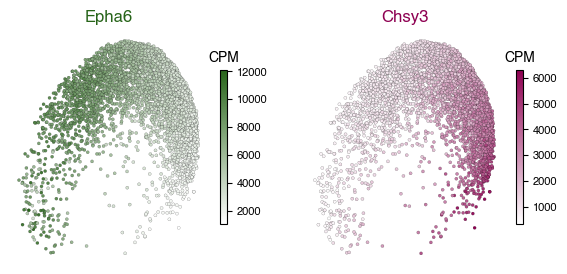

In [31]:
# Visualize Selected Example Genes on PCA
print("Visualizing selected example genes on PCA...")

# showinggenelist = ['Epha6', 'Lrrtm4', 'Dab1']  # Three key genes
# foocol = [high_col, 'gray', low_col]
# cmapnames = [high_cmap, 'Grays', low_cmap, ]
showinggenelist = ['Epha6', 'Chsy3']  # Three key genes
foocol = [high_col, low_col]
cmapnames = [high_cmap, low_cmap, ]

s = 5

fig, axes = plt.subplots(1, 2, figsize=(7, 5))
for t, gene in enumerate(showinggenelist):
    ax = axes[t]
    ax.set_title(gene, color=foocol[t])
    sca = ax.scatter(
        adata_sc.obsm['X_pca'][:, 0],
        adata_sc.obsm['X_pca'][:, 1],
        c=adata_sc.layers['originalBN'][:,np.where(adata_sc.var_names==gene)[0][0]]*cpm_scl,
        s=s, cmap=cmapnames[t], edgecolor='k', linewidth=0.1
    )
    ax.set_aspect('equal')
    cbar = plt.colorbar(sca, shrink=0.4, orientation='vertical')
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("CPM", ha='center', va='bottom')
    
    # Clean up appearance
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

save_figure("example_genes_pca")
plt.show()

In [32]:
cpm_scl

1000000.0

In [33]:
posgenes.shape

(50,)

Using 47 genes for heatmap (20 pos, 7 U-shaped, 20 neg)
Saving figure to: /output/figures/snRNAseq/gene_expression_heatmap_foo.svg
Saving figure to: /output/figures/snRNAseq/gene_expression_heatmap_foo.png


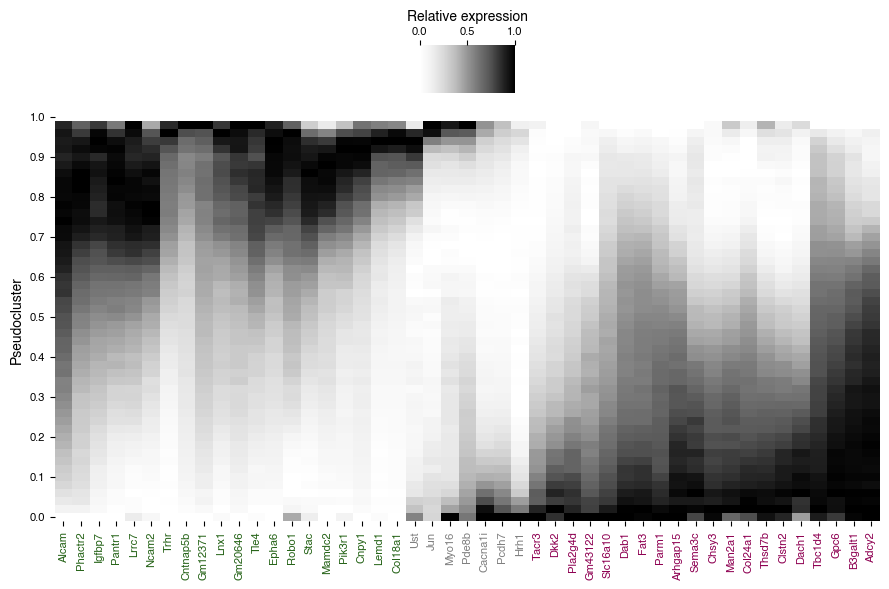

Row order for external use: [16, 12, 11, 5, 8, 10, 0, 2, 9, 6, 15, 13, 1, 17, 3, 18, 14, 7, 19, 4, 44, 45, 46, 41, 42, 40, 43, 30, 28, 33, 37, 24, 26, 23, 22, 29, 31, 20, 36, 27, 39, 38, 32, 25, 21, 34, 35]
All your genes for external use: ['Trhr', 'Epha6', 'Cntnap5b', 'Stac', 'Col18a1', 'Pantr1', 'Lnx1', 'Cnpy1', 'Lrrc7', 'Gm12371', 'Ncam2', 'Igfbp7', 'Phactr2', 'Tle4', 'Pik3r1', 'Gm20646', 'Alcam', 'Robo1', 'Mamdc2', 'Lemd1', 'Chsy3', 'Gpc6', 'Parm1', 'Fat3', 'Slc16a10', 'Tbc1d4', 'Dab1', 'Col24a1', 'Dkk2', 'Arhgap15', 'Tacr3', 'Sema3c', 'Dach1', 'Pla2g4d', 'B3galt1', 'Adcy2', 'Man2a1', 'Gm43122', 'Clstn2', 'Thsd7b', 'Pcdh7', 'Pde8b', 'Cacna1i', 'Hrh1', 'Ust', 'Jun', 'Myo16']


In [34]:
T_posneg = 20 
T_u = len(u_genes)
n_pos = min(T_posneg, len(posgenes))
n_neg = min(T_posneg, len(neggenes))
n_u   = T_u   
allyourgenes = (
    list(posgenes)[:n_pos] +
    list(neggenes)[:n_neg] +
    list(u_genes)[:n_u])
print(f"Using {len(allyourgenes)} genes for heatmap "
      f"({n_pos} pos, {n_u} U-shaped, {n_neg} neg)")


inputheatmap = (
    adata_sc[:, allyourgenes]
    .X[trajectory['order']]
    .copy()[np.argsort(scores_0_1)]
    .T
)
ordered_data, row_order = heatmap.get_final_heatmap(inputheatmap, order_mode="cluster")

tick_colors = []
for orig_idx in row_order:
    if orig_idx < n_pos:
        # first block: positive genes
        tick_colors.append(high_col)
    elif orig_idx < n_pos + n_neg:
        # second block: negative genes
        tick_colors.append(low_col)
    else:
        # last block: U-shaped genes
        tick_colors.append('gray')

# Create and style heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(
    ordered_data.T,
    cmap='Greys',
    cbar_kws={
        'location': 'top',
        'label': 'Relative expression',
        'shrink': 0.3,
        'aspect': 2,
        'fraction': 0.1})

# Set x-tick labels and colors
ax = plt.gca()
xtick_labels = [allyourgenes[l] for l in row_order]   # len = n_genes
n_genes = len(xtick_labels)
xtick_positions = np.arange(n_genes) + 0.5  # centers of cells
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=90)
for tick, color in zip(ax.get_xticklabels(), tick_colors):
    tick.set_color(color)



    
# Set y-tick labels
plt.ylabel('Pseudocluster')
plt.gca().invert_yaxis()
plt.yticks(
    np.arange(11) * (ordered_data.shape[1] // 10) + 0.5,
    np.around(np.linspace(0, 1, 11), 1),
    rotation=0
)

plt.grid(False)
plt.tight_layout()
save_figure("gene_expression_heatmap_foo")
plt.show()

# Export row order for integration with MERFISH data
print("Row order for external use:", row_order)
print("All your genes for external use:", allyourgenes)



Using 47 genes for heatmap (20 pos, 7 U-shaped, 20 neg)
Saving figure to: /output/figures/snRNAseq/gene_expression_heatmap.svg
Saving figure to: /output/figures/snRNAseq/gene_expression_heatmap.png


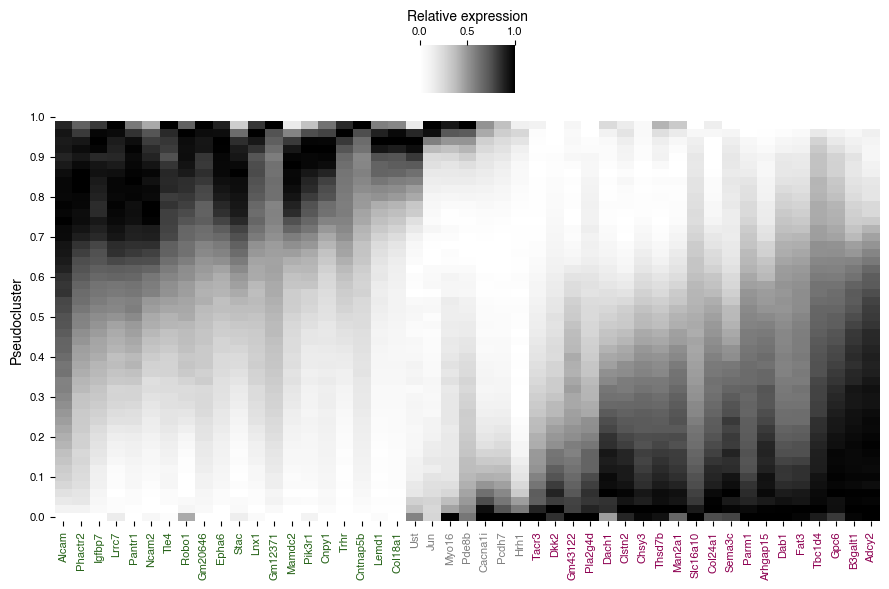

Row order for external use: [16 12 11  8  5 10 13 17 15  1  3  6  9 18 14  7  0  2 19  4 24 25 26 21
 22 20 23 37 35 44 40 39 45 27 46 43 31 34 38 29 36 33 30 32 28 41 42]
All your genes for external use: ['Trhr', 'Epha6', 'Cntnap5b', 'Stac', 'Col18a1', 'Pantr1', 'Lnx1', 'Cnpy1', 'Lrrc7', 'Gm12371', 'Ncam2', 'Igfbp7', 'Phactr2', 'Tle4', 'Pik3r1', 'Gm20646', 'Alcam', 'Robo1', 'Mamdc2', 'Lemd1', 'Pcdh7', 'Pde8b', 'Cacna1i', 'Hrh1', 'Ust', 'Jun', 'Myo16', 'Chsy3', 'Gpc6', 'Parm1', 'Fat3', 'Slc16a10', 'Tbc1d4', 'Dab1', 'Col24a1', 'Dkk2', 'Arhgap15', 'Tacr3', 'Sema3c', 'Dach1', 'Pla2g4d', 'B3galt1', 'Adcy2', 'Man2a1', 'Gm43122', 'Clstn2', 'Thsd7b']


In [35]:
# this is yohs plotting code 

T_posneg = 20 
T_u = len(u_genes)
n_pos = min(T_posneg, len(posgenes))
n_neg = min(T_posneg, len(neggenes))
n_u   = T_u   
allyourgenes = (
    list(posgenes)[:n_pos] +
    list(u_genes)[:n_u] +
    list(neggenes)[:n_neg])
print(f"Using {len(allyourgenes)} genes for heatmap "
      f"({n_pos} pos, {n_u} U-shaped, {n_neg} neg)")


inputheatmap = (
    adata_sc[:, allyourgenes]
    .X[trajectory['order']]
    .copy()[np.argsort(scores_0_1)]
    .T
)
# --- CUSTOM ORDERING (per-category rules) ---
n_out = 50
reduced = heatmap.downsample_moving_avg(inputheatmap, n_out=n_out)
scaled_data = heatmap.scaling(reduced)

total_intensity = np.sum(scaled_data, axis=1)

# Center of mass along pseudocluster axis (used for u-shaped ordering)
x_bins = np.arange(scaled_data.shape[1])
weights_com = np.sum(scaled_data, axis=1)
weights_com[weights_com < 1e-9] = 1.0
com = np.sum(scaled_data * x_bins, axis=1) / weights_com

pos_indices = np.arange(n_pos)
u_indices   = np.arange(n_pos, n_pos + n_u)
neg_indices = np.arange(n_pos + n_u, n_pos + n_u + n_neg)

# Green (pos):    high density → low density (descending total intensity)
pos_sorted = pos_indices[np.argsort(total_intensity[pos_indices])[::-1]]
# Grey (u-shaped): dense at high pseudocluster score first (descending COM)
u_sorted   = u_indices[np.argsort(com[u_indices])[::-1]]
# Magenta (neg):  low density → high density (ascending total intensity)
neg_sorted = neg_indices[np.argsort(total_intensity[neg_indices])]

row_order = np.concatenate([pos_sorted, u_sorted, neg_sorted])
ordered_data = scaled_data[row_order]
# ---------------------------------------------------

tick_colors = []
for orig_idx in row_order:
    if orig_idx < n_pos:
        tick_colors.append(high_col)
    elif orig_idx < n_pos + n_u:
        tick_colors.append('gray')
    else:
        tick_colors.append(low_col)

# Create and style heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(
    ordered_data.T,
    cmap='Greys',
    cbar_kws={
        'location': 'top',
        'label': 'Relative expression',
        'shrink': 0.3,
        'aspect': 2,
        'fraction': 0.1})

# Set x-tick labels and colors
ax = plt.gca()
xtick_labels = [allyourgenes[l] for l in row_order]   # len = n_genes
n_genes = len(xtick_labels)
xtick_positions = np.arange(n_genes) + 0.5  # centers of cells
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=90)
for tick, color in zip(ax.get_xticklabels(), tick_colors):
    tick.set_color(color)


    
# Set y-tick labels
plt.ylabel('Pseudocluster')
plt.gca().invert_yaxis()
plt.yticks(
    np.arange(11) * (ordered_data.shape[1] // 10) + 0.5,
    np.around(np.linspace(0, 1, 11), 1),
    rotation=0
)

plt.grid(False)
plt.tight_layout()
save_figure("gene_expression_heatmap")
plt.show()

# Export row order for integration with MERFISH data
print("Row order for external use:", row_order)
print("All your genes for external use:", allyourgenes)

In [36]:
import pickle

output_file = os.path.join(TMP_OUT_DIR, 'allyourgenes.pkl')

# Genes in clustered order (the order you actually plotted)
genes_clustered = [allyourgenes[l] for l in row_order]

# Pack a more informative structure
pickle_payload = {
    "genes_clustered": genes_clustered,   # gene order used in this heatmap
    "genes_original": allyourgenes,      # pos + neg + U in original concatenation order
    "n_pos": n_pos,
    "n_neg": n_neg,
    "n_u": n_u,
    "row_order": row_order.tolist() if hasattr(row_order, "tolist") else list(row_order),
}

with open(output_file, "wb") as f:
    pickle.dump(pickle_payload, f)

print(f"Saved allyourgenes metadata to {output_file}")

Saved allyourgenes metadata to /output/allyourgenes.pkl


In [37]:
# Analysis Summary
print("Analysis complete! All visualizations have been saved to:", fig_path)
print("\nSummary of analysis:")
print(f"- Analyzed {adata_sc.n_obs} cells with {adata_sc.n_vars} genes")
print(f"- Identified trajectory in {n_dims}-dimensional PCA space")
print(f"- Top positive correlation gene: {list(posgenes)[0]}")
print(f"- Top negative correlation gene: {list(neggenes)[0]}")
print(f"- Created visualizations for {T*3} genes across multiple projections")
print(f"- Generated heatmap with {len(allyourgenes)} genes ordered by expression pattern")

Analysis complete! All visualizations have been saved to: /output/figures/snRNAseq

Summary of analysis:
- Analyzed 4845 cells with 1502 genes
- Identified trajectory in 10-dimensional PCA space
- Top positive correlation gene: Trhr
- Top negative correlation gene: Chsy3
- Created visualizations for 21 genes across multiple projections
- Generated heatmap with 47 genes ordered by expression pattern


In [38]:
(np.sum(adata_sc.raw.X, axis = 0)<3).sum()

1